## Group Equivariant canonicalization for an Invariant Task (Image Classification with ViT-Base)
In this notebook, we test whether the group equivariant image canonicalizer can generate a canonical orientation properly for sample images which can be processed by the prediction network. We also visualize the ground truth and predicted class from a prediction network, which is Vision Transformer ([Dosovitskiy et. al, 2020](https://arxiv.org/abs/2010.11929)). Further we consider the group to be $C_4$ which is rotation of 4 discrete rotations.

In [1]:
import torch
from tqdm import tqdm

from equiadapt.images.canonicalization_networks.escnn_networks import ESCNNEquivariantNetwork
from equiadapt.images.canonicalization.discrete_group import GroupEquivariantImageCanonicalization
from equiadapt.common.basecanonicalization import IdentityCanonicalization

from examples.images.classification.prepare import RotatedMNISTDataModule
from examples.images.classification.inference_utils import GroupInference
from examples.images.classification.model_utils import get_prediction_network


In [2]:
# get device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
class DatasetHyperparams:
    def __init__(self):
        self.dataset_name = "mnist" # Name of the dataset to use
        self.data_path = "/data/rot_mnist_specific" # Path to the dataset
        self.augment = 0 # Whether to use data augmentation (1) or not (0)
        self.num_workers = 4 # Number of workers for data loading
        self.batch_size = 64 # Number of samples per batch
        
dataset_hyperparams = DatasetHyperparams()
data = RotatedMNISTDataModule(hyperparams=dataset_hyperparams)

data.setup()
train_loader = data.train_dataloader()

data.setup(stage="test")
test_loader = data.test_dataloader()

Train dataset size:  10000
Valid dataset size:  2000
Test dataset size:  50000


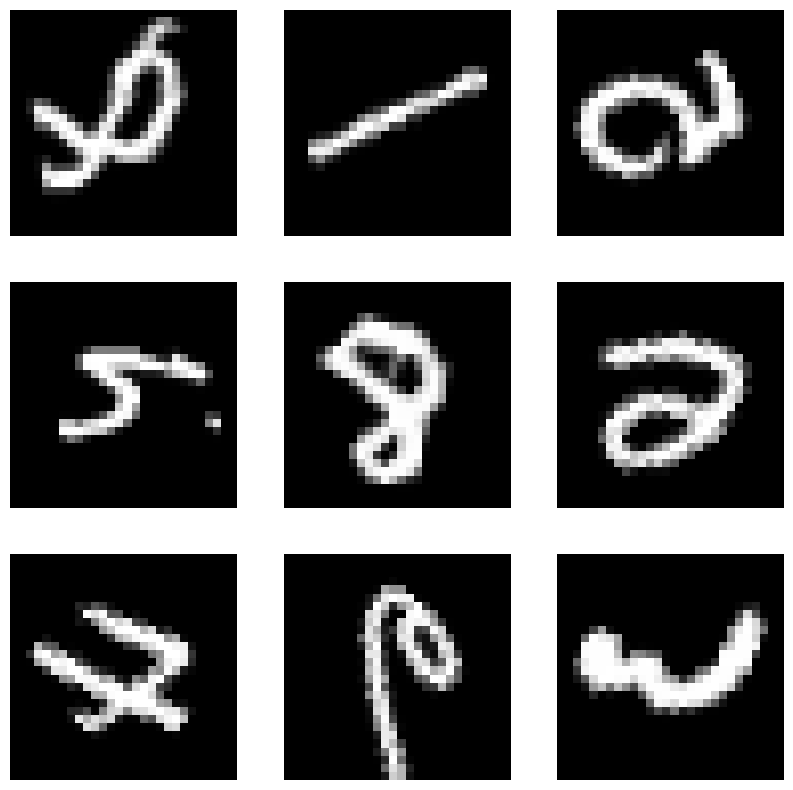

In [4]:
#visualize a batch of images
import matplotlib.pyplot as plt
imag = next(iter(train_loader))[0]
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(imag[i].squeeze(), cmap='gray')
    plt.axis('off')

In [5]:
loss_fn, image_shape, num_classes = torch.nn.CrossEntropyLoss(), (1, 28, 28), 10

# get the prediction network, which in this case is Vision Transformer
prediction_network = get_prediction_network(
    architecture = "resnet50",
    dataset_name = "rotated_mnist",
    use_pretrained = True,
    freeze_encoder = False,
    input_shape = image_shape,
    num_classes = num_classes
).to(device)

In [6]:
# design canonicalization hyperparams class
class CanonicalizationHyperparams:
    def __init__(self):
        self.canonicalization_type="group_equivariant" # canonicalization type network
        self.network_type = "escnn" # group equivariant canonicalization
        self.resize_shape = 96 # resize shape for the canonicalization network
        self.network_hyperparams = {
            "kernel_size": 5, # Kernel size for the canonization network
            "out_channels": 32, # Number of output channels for the canonization network
            "num_layers": 3, # Number of layers in the canonization network
            "group_type": "rotation", # Type of group for the canonization network
            "num_rotations": 4, # Number of rotations for the canonization network 
        }
        self.beta = 1.0 
        self.input_crop_ratio = 0.8
        
canonicalization_hyperparams = CanonicalizationHyperparams()

canonicalization_network = ESCNNEquivariantNetwork(
                        image_shape,
                        **canonicalization_hyperparams.network_hyperparams,
                    ).to(device)

canonicalizer = GroupEquivariantImageCanonicalization(
            canonicalization_network,
            canonicalization_hyperparams,
            image_shape
        ).to(device)

In [7]:
class InferenceHyperparams:
    def __init__(self):
        self.method = "group"
        self.group_type = "rotation"
        self.num_rotations = 4
        
inference_method = GroupInference(
        canonicalizer,
        prediction_network,
        num_classes,
        InferenceHyperparams(),
        image_shape
    )

### Fine-tuning ViT on STL10 with a $C_4$ equivariant canonicalization network

In [8]:
optimizer = torch.optim.AdamW([
        {'params': prediction_network.parameters(), 'lr': 1e-3},
        {'params': canonicalizer.parameters(), 'lr': 1e-3},
    ])

In [9]:
from torch.optim.lr_scheduler import MultiStepLR
import pytorch_lightning as pl
class ImageClassifierPipeline(pl.LightningModule):
    def __init__(self,canonicalization_type="group_equivariant", image_shape=image_shape, num_classes=num_classes,prediction_network=None, canonicalizer=None, inference_method=None, max_epochs=200, task_weight=1.0, prior_weight=100.0,
                 group_contrast_weight=0.0001, prediction_lr=1e-3, canonicalization_lr=1e-3,dataset_name="rotated_mnist",prediction_network_architecture="resnet50"):
        """

        Args:
            image_shape:
            num_classes:
            hyperparams:
        """
        super().__init__()

        self.loss=torch.nn.CrossEntropyLoss()
        self.prediction_network = prediction_network
        self.prediction_network_architecture = prediction_network_architecture

        self.canonicalizer =  canonicalizer
        self.num_classes = num_classes



        self.inference_method = inference_method

        self.max_epochs = max_epochs
        self.image_shape = image_shape
        self.task_weight = task_weight
        self.prior_weight = prior_weight
        self.canonicalization_type = canonicalization_type
        self.group_contrast_weight = group_contrast_weight
        self.prediction_lr = prediction_lr
        self.canonicalization_lr = canonicalization_lr
        self.dataset_name = dataset_name

    def training_step(self, batch: torch.Tensor):
        x, y = batch
        batch_size, num_channels, height, width = x.shape

        # assert that the input is in the right shape
        assert (num_channels, height, width) == self.image_shape

        training_metrics = {}
        loss, acc = 0.0, 0.0

        # canonicalize the input data
        # For the vanilla model, the canonicalization is the identity transformation
        x_canonicalized = self.canonicalizer(x)

        # add group contrast loss while using optmization based canonicalization method
        if "opt" in self.canonicalization_type:
            group_contrast_loss = self.canonicalizer.get_optimization_specific_loss()
            loss += (
                group_contrast_loss
                * self.group_contrast_weight
            )
            training_metrics.update(
                {"train/optimization_specific_loss": group_contrast_loss}
            )

        if self.task_weight:
            logits = self.prediction_network(x_canonicalized)

            task_loss = self.loss(logits, y)
            loss += self.task_weight * task_loss

            # Get the predictions and calculate the accuracy
            preds = logits.argmax(dim=-1)
            acc = (preds == y).float().mean()

            training_metrics.update({"train/task_loss": task_loss, "train/acc": acc})

        # Add prior regularization loss if the prior weight is non-zero
        if self.prior_weight:
            prior_loss = self.canonicalizer.get_prior_regularization_loss()
            loss += prior_loss * self.prior_weight
            metric_identity = self.canonicalizer.get_identity_metric()
            training_metrics.update(
                {
                    "train/prior_loss": prior_loss,
                    "train/identity_metric": metric_identity,
                }
            )

        training_metrics.update(
            {
                "train/loss": loss,
            }
        )

        # Log the training metrics
        self.log_dict(training_metrics, prog_bar=True)
        assert not torch.isnan(loss), "Loss is NaN"

        return {"loss": loss, "acc": acc}

    def validation_step(self, batch: torch.Tensor):
        x, y = batch

        batch_size, num_channels, height, width = x.shape

        # assert that the input is in the right shape
        assert (num_channels, height, width) == self.image_shape

        validation_metrics = {}

        # canonicalize the input data
        # For the vanilla model, the canonicalization is the identity transformation
        x_canonicalized = self.canonicalizer(x)

        # Forward pass through the prediction network as you'll normally do
        logits = self.prediction_network(x_canonicalized)

        # Get the predictions and calculate the accuracy
        preds = logits.argmax(dim=-1)
        acc = (preds == y).float().mean()

        # Log the identity metric if the prior weight is non-zero
        if self.prior_weight:
            metric_identity = self.canonicalizer.get_identity_metric()
            validation_metrics.update({"train/identity_metric": metric_identity})

        # Logging to TensorBoard by default
        validation_metrics.update({"val/acc": acc})

        self.log_dict(
            {key: value.to(self.device) for key, value in validation_metrics.items()},
            prog_bar=True,
            sync_dist=True,
        )

        return {"acc": acc}

    def test_step(self, batch: torch.Tensor):
        x, y = batch
        batch_size, num_channels, height, width = x.shape

        # assert that the input is in the right shape
        assert (num_channels, height, width) == self.image_shape

        test_metrics = self.inference_method.get_inference_metrics(x, y)

        # Log the test metrics
        self.log_dict(
            {key: value.to(self.device) for key, value in test_metrics.items()},
            prog_bar=True,
            sync_dist=True,
        )

        return test_metrics

    def configure_optimizers(self):
        if (
            "resnet" in self.prediction_network_architecture
            and "mnist" not in self.dataset_name
        ):
            print("using SGD optimizer")
            optimizer = torch.optim.SGD(
                [
                    {
                        "params": self.prediction_network.parameters(),
                        "lr": self.prediction_lr,
                    },
                    {
                        "params": self.canonicalizer.parameters(),
                        "lr": self.canonicalization_lr,
                    },
                ],
                momentum=0.9,
                weight_decay=5e-4,
            )

            if self.max_epochs > 100:
                milestones = [
                    self.trainer.max_epochs // 6,
                    self.trainer.max_epochs // 3,
                    self.trainer.max_epochs // 2,
                ]
            else:
                milestones = [
                    self.trainer.max_epochs // 3,
                    self.trainer.max_epochs // 2,
                ]  # for small training epochs

            scheduler_dict = {
                "scheduler": MultiStepLR(
                    optimizer,
                    milestones=milestones,
                    gamma=0.1,
                ),
                "interval": "epoch",
            }
            return {"optimizer": optimizer, "lr_scheduler": scheduler_dict}
        else:
            print(f"using AdamW optimizer")
            optimizer = torch.optim.AdamW(
                [
                    {
                        "params": self.prediction_network.parameters(),
                        "lr": self.prediction_lr,
                    },
                    {
                        "params": self.canonicalizer.parameters(),
                        "lr": self.canonicalization_lr,
                    },
                ]
            )
            return optimizer

pipeline = ImageClassifierPipeline()

In [14]:
cls = ImageClassifierPipeline(
    canonicalization_type=canonicalization_hyperparams.canonicalization_type,
    image_shape=image_shape,
    num_classes=num_classes,
    prediction_network=prediction_network,
    canonicalizer=canonicalizer,
    inference_method=inference_method,
    max_epochs=40,
    task_weight=1.0,
    prior_weight=1.0,
    group_contrast_weight=0.0001,
    prediction_lr=1e-3,
    canonicalization_lr=1e-3,
    dataset_name="rotated_mnist"
    ,prediction_network_architecture="resnet50"
)

In [15]:
from model.classifier import MyProgressBar


In [16]:
trainer = pl.Trainer(
    accelerator="gpu",
    devices=1,
    max_epochs=40,
    enable_progress_bar=True,
    logger=True,
    log_every_n_steps=10,
    enable_checkpointing=False,
    callbacks=[MyProgressBar()],
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [19]:

canonicalization_network

ESCNNEquivariantNetwork(
  (eqv_network): SequentialModule(
    (0): R2Conv([C4_on_R2[(None, 4)]: {irrep_0 (x1)}(1)], [C4_on_R2[(None, 4)]: {regular (x32)}(128)], kernel_size=5, stride=1)
    (1): InnerBatchNorm([C4_on_R2[(None, 4)]: {regular (x32)}(128)], eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True, type=[C4_on_R2[(None, 4)]: {regular (x32)}(128)])
    (3): PointwiseDropout()
    (4): R2Conv([C4_on_R2[(None, 4)]: {regular (x32)}(128)], [C4_on_R2[(None, 4)]: {regular (x32)}(128)], kernel_size=5, stride=1)
    (5): InnerBatchNorm([C4_on_R2[(None, 4)]: {regular (x32)}(128)], eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True, type=[C4_on_R2[(None, 4)]: {regular (x32)}(128)])
    (7): PointwiseDropout()
    (8): R2Conv([C4_on_R2[(None, 4)]: {regular (x32)}(128)], [C4_on_R2[(None, 4)]: {regular (x32)}(128)], kernel_size=5, stride=1)
  )
)

In [17]:
trainer.fit(
    cls,
    data
)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name               | Type                                  | Params | Mode 
-------------------------------------------------------------------------------------
0 | loss               | CrossEntropyLoss                      | 0      | train
1 | prediction_network | PredictionNetwork                     | 23.5 M | train
2 | canonicalizer      | GroupEquivariantImageCanonicalization | 90.7 K | train
-------------------------------------------------------------------------------------
23.6 M    Trainable params
0         Non-trainable params
23.6 M    Total params
94.442    Total estimated model params size (MB)
176       Modules in train mode
0         Modules in eval mode


Train dataset size:  10000
Valid dataset size:  2000
using AdamW optimizer
Epoch 5:  25%|██▌       | 40/157 [00:04<00:12,  9.45it/s, v_num=158, train/task_loss=0.0462, train/acc=0.984, train/prior_loss=1.380, train/identity_metric=0.281, train/loss=1.430, val/acc=0.957] 


Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

In [14]:
test_tqdm_bar = tqdm(enumerate(test_loader), desc=f"Testing", total=len(test_loader))
total_acc, total_group_acc = 0, 0
for batch_idx, batch in test_tqdm_bar:
    x, y = batch
    x = x.to(device)
    y = y.to(device)
    
    batch_size, num_channels, height, width = x.shape
    assert (num_channels, height, width) == image_shape

    test_metrics = inference_method.get_inference_metrics(x, y)
    
    total_acc += test_metrics["test/acc"]
    total_group_acc += test_metrics["test/group_acc"]
    
    
print(f"Test Accuracy: {total_acc/len(test_loader):.3f}")
print(f"Test Group Accuracy: {total_group_acc/len(test_loader):.3f}")


Testing: 100%|██████████| 782/782 [01:15<00:00, 10.40it/s]

Test Accuracy: 0.967
Test Group Accuracy: 0.968


In [ ]:
epochs = 200

# finetuning the prediction network with the canonicalizer for STL10 dataset
for epoch in range(epochs):
    tqdm_bar = tqdm(enumerate(train_loader), desc=f"Epoch {epoch}", total=len(train_loader))

    total_acc, total_loss, total_task_loss, total_prior_loss = 0.0, 0.0, 0.0, 0.0
    for batch_idx, batch in tqdm_bar:

        optimizer.zero_grad()

        x, y = batch
        x = x.to(device)
        y = y.to(device)

        batch_size, num_channels, height, width = x.shape
        assert (num_channels, height, width) == image_shape

        training_metrics = {}
        loss = 0.0

        # canonicalize the input data
        x_canonicalized = canonicalizer(x)

        # Get the predictions from the prediction network
        logits = prediction_network(x_canonicalized)

        # Evaluate the task loss
        task_loss = loss_fn(logits, y)
        loss += task_loss

        # Add prior regularization loss
        prior_loss = canonicalizer.get_prior_regularization_loss()
        loss += prior_loss * 100

        # Get the predictions and calculate the accuracy
        preds = logits.argmax(dim=-1)
        acc = (preds == y).float().mean()


        # Logging the training metrics
        total_acc += acc.item()
        total_loss += loss.item()
        total_task_loss += task_loss.item()
        total_prior_loss += prior_loss.item()
        training_metrics.update({
                "acc": total_acc / (batch_idx + 1),
                "task_loss": total_task_loss / (batch_idx + 1),
                "prior_loss": total_prior_loss / (batch_idx + 1),
                "loss": total_loss / (batch_idx + 1),
            })

        # Usual training steps
        loss.backward()

        optimizer.step()

        # Log the training metrics
        tqdm_bar.set_postfix(training_metrics)

### Fine-tuning ViT on STL10 without canonicalization network

In [10]:
# redefine the prediction network (to reset the weights)
prediction_network = get_prediction_network(
    architecture = "vit",
    dataset_name = "stl10",
    use_pretrained = True,
    freeze_encoder = False,
    input_shape = image_shape,
    num_classes = num_classes
).to(device)


# Initialize tqdm progress bar
optimizer = torch.optim.AdamW([
        {'params': prediction_network.parameters(), 'lr': 1e-5},
    ])

epochs = 20

# finetuning the prediction network with the canonicalizer for STL10 dataset

for epoch in range(epochs):
    tqdm_bar = tqdm(enumerate(train_loader), desc=f"Epoch {epoch}", total=len(train_loader))
                 
    total_acc, total_loss, total_task_loss = 0.0, 0.0, 0.0
    for batch_idx, batch in tqdm_bar:
        
        optimizer.zero_grad()
        
        x, y = batch
        x = x.to(device)
        y = y.to(device)
        
        batch_size, num_channels, height, width = x.shape
        assert (num_channels, height, width) == image_shape

        training_metrics = {}
        loss = 0.0
        
        # Get the predictions from the prediction network
        logits = prediction_network(x)
            
        # Evaluate the task loss
        task_loss = loss_fn(logits, y)
        loss += task_loss
            
        # Get the predictions and calculate the accuracy 
        preds = logits.argmax(dim=-1)
        acc = (preds == y).float().mean()
            
            
        # Logging the training metrics
        total_acc += acc.item()
        total_loss += loss.item()
        total_task_loss += task_loss.item()
        training_metrics.update({
                "acc": total_acc / (batch_idx + 1),
                "task_loss": total_task_loss / (batch_idx + 1),
                "loss": total_loss / (batch_idx + 1),
            })  
        
        # Usual training steps
        loss.backward()
        
        optimizer.step()
        
        # Log the training metrics
        tqdm_bar.set_postfix(training_metrics)

Epoch 19: 100%|██████████| 79/79 [00:34<00:00,  2.31it/s, acc=0.999, task_loss=0.00595, loss=0.00595]


In [11]:
class InferenceHyperparams:
    def __init__(self):
        self.method = "group"
        self.group_type = "rotation"
        self.num_rotations = 4
        
inference_method = GroupInference(
        IdentityCanonicalization(),
        prediction_network,
        num_classes,
        InferenceHyperparams(),
        image_shape
    )

test_tqdm_bar = tqdm(enumerate(test_loader), desc=f"Testing", total=len(test_loader))
total_acc, total_group_acc = 0, 0
for batch_idx, batch in test_tqdm_bar:
    x, y = batch
    x = x.to(device)
    y = y.to(device)
    
    batch_size, num_channels, height, width = x.shape
    assert (num_channels, height, width) == image_shape

    test_metrics = inference_method.get_inference_metrics(x, y)
    
    total_acc += test_metrics["test/acc"]
    total_group_acc += test_metrics["test/group_acc"]
    
    
print(f"Test Accuracy: {total_acc/len(test_loader):.3f}")
print(f"Test Group Accuracy: {total_group_acc/len(test_loader):.3f}")


Testing:   0%|          | 0/125 [00:00<?, ?it/s]

Testing: 100%|██████████| 125/125 [01:12<00:00,  1.73it/s]

Test Accuracy: 0.982
Test Group Accuracy: 0.775


C:\Users\Lindner\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe: can't open file 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\experiment_notebooks\\train.py': [Errno 2] No such file or directory


In [52]:
from torch.quasirandom import SobolEngine
from utils.transform_sequence import TransformSequence


def sample_initial_parameters_sobol(lower_bounds, upper_bounds, batch_size, n_samples=None, device=None, dtype=None):
        """
        Sample parameters using Sobol sequence.
        """
        if n_samples is None:
            return TransformSequence.sample_initial_parameters(lower_bounds, upper_bounds, batch_size,
                                                               device=device, dtype=dtype)

        if device is None:
            device = lower_bounds.device
        if dtype is None:
            dtype = lower_bounds.dtype

        dim = lower_bounds.numel()
        span = upper_bounds - lower_bounds


            # new engine per batch for independent scrambles
        engine = SobolEngine(dimension=dim, scramble=True)
        sobol = engine.draw(batch_size*n_samples).to(device=device, dtype=dtype)  # (n_samples, dim)
        out = sobol * span.view(1, dim) + lower_bounds.view(1, dim)
        out = out.view(batch_size, n_samples,dim)# (batch_size, n_samples, dim)
        return out

In [53]:
import torch

In [54]:
res  = sample_initial_parameters_sobol(torch.tensor((0,0)),torch.tensor((1,1)), 10, n_samples=20, device="cpu", dtype=torch.float32)

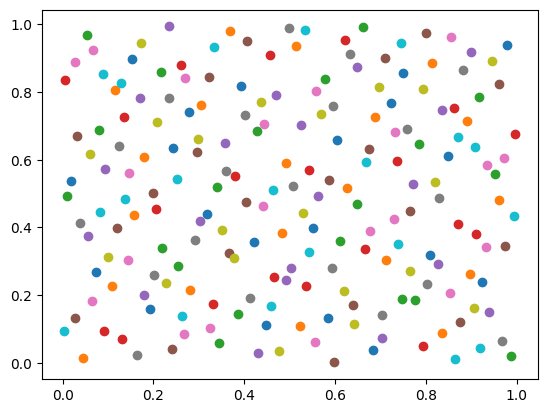

In [55]:
import matplotlib.pyplot as plt
for i in range(res.shape[0]):
    plt.scatter(res[i,:,0].numpy(), res[i,:,1].numpy())
